Cell 1 — Imports & Paths

In [21]:
# Cell 1 — Imports & Paths
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import deque
import onnxruntime as ort
import time

# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT     = Path("D:/Projects/oras")
YOLO_ONNX        = PROJECT_ROOT / "ml/models/tool_detection.onnx"
TCN_ONNX         = PROJECT_ROOT / "models/phase/tcn_phase.onnx"
FRAMES_DIR       = PROJECT_ROOT / "ml/datasets/cholec80_frames"
OUTPUT_DIR       = PROJECT_ROOT / "ml/outputs/inference"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants (must match training) ───────────────────────────────────────────
TOOL_COLS = [
    "grasper", "bipolar", "hook", "scissors",
    "clipper", "irrigator", "specimenbag"
]
PHASE_NAMES = [
    "CalotTriangleDissection", "CleaningCoagulation", "ClippingCutting",
    "GallbladderDissection", "GallbladderPackaging",
    "GallbladderRetraction", "Preparation"
]
SEQ_LEN    = 32
IMG_SIZE   = 640    # YOLOv8 input size
CONF_THRES = 0.25   # YOLO confidence threshold
IOU_THRES  = 0.45   # NMS IoU threshold

# Verify models exist
print(f"YOLO  ONNX : {YOLO_ONNX.exists()}  → {YOLO_ONNX}")
print(f"TCN   ONNX : {TCN_ONNX.exists()}   → {TCN_ONNX}")

YOLO  ONNX : True  → D:\Projects\oras\ml\models\tool_detection.onnx
TCN   ONNX : True   → D:\Projects\oras\models\phase\tcn_phase.onnx


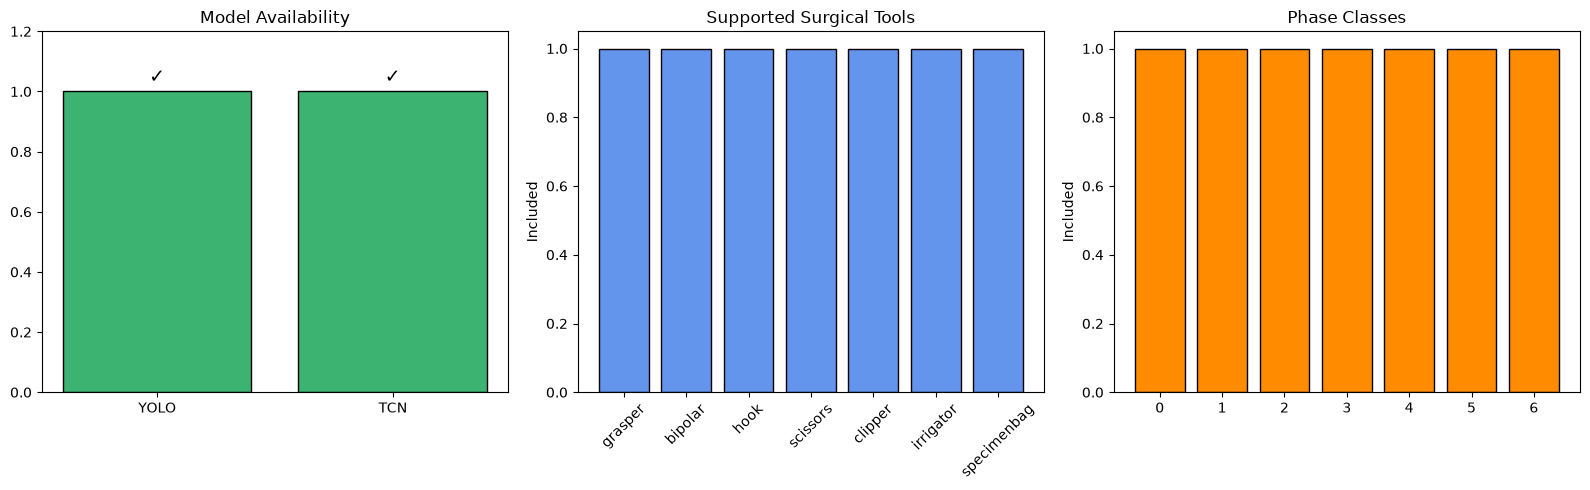

In [22]:
# Cell 1.1 — Inference Environment Overview (Matplotlib)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model Availability
model_status = [YOLO_ONNX.exists(), TCN_ONNX.exists()]
colors = ["mediumseagreen" if s else "tomato" for s in model_status]

axes[0].bar(["YOLO", "TCN"], [1, 1], color=colors, edgecolor="black")
axes[0].set_ylim(0, 1.2)
axes[0].set_title("Model Availability")
for i, status in enumerate(model_status):
    axes[0].text(i, 1.03, "✓" if status else "✗",
                 ha="center", fontsize=14, fontweight="bold")

# Tool Classes
axes[1].bar(
    TOOL_COLS,
    np.ones(len(TOOL_COLS)),
    color="cornflowerblue",
    edgecolor="black"
)
axes[1].set_title("Supported Surgical Tools")
axes[1].set_ylabel("Included")
axes[1].tick_params(axis="x", rotation=45)

# Surgical Phase Classes
axes[2].bar(
    range(len(PHASE_NAMES)),
    np.ones(len(PHASE_NAMES)),
    color="darkorange",
    edgecolor="black"
)
axes[2].set_title("Phase Classes")
axes[2].set_xticks(range(len(PHASE_NAMES)))
axes[2].set_xticklabels(range(len(PHASE_NAMES)))
axes[2].set_ylabel("Included")

plt.tight_layout()
plt.show()

Cell 2 — Load ONNX Sessions

In [23]:
# Cell 2 — Load ONNX Sessions
# CPU provider is fine — ONNX Runtime handles GPU separately from PyTorch
yolo_session = ort.InferenceSession(
    str(YOLO_ONNX),
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
tcn_session = ort.InferenceSession(
    str(TCN_ONNX),
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

yolo_input_name  = yolo_session.get_inputs()[0].name
yolo_output_name = yolo_session.get_outputs()[0].name
tcn_input_name   = tcn_session.get_inputs()[0].name
tcn_output_name  = tcn_session.get_outputs()[0].name

print(f"YOLO  input : '{yolo_input_name}'  shape: {yolo_session.get_inputs()[0].shape}")
print(f"YOLO  output: '{yolo_output_name}' shape: {yolo_session.get_outputs()[0].shape}")
print(f"TCN   input : '{tcn_input_name}'   shape: {tcn_session.get_inputs()[0].shape}")
print(f"TCN   output: '{tcn_output_name}'  shape: {tcn_session.get_outputs()[0].shape}")

YOLO  input : 'images'  shape: [1, 3, 640, 640]
YOLO  output: 'output0' shape: [1, 11, 8400]
TCN   input : 'tool_sequence'   shape: ['batch', 32, 16]
TCN   output: 'phase_logits'  shape: ['batch', 7]


d:\Projects\oras\ml\venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


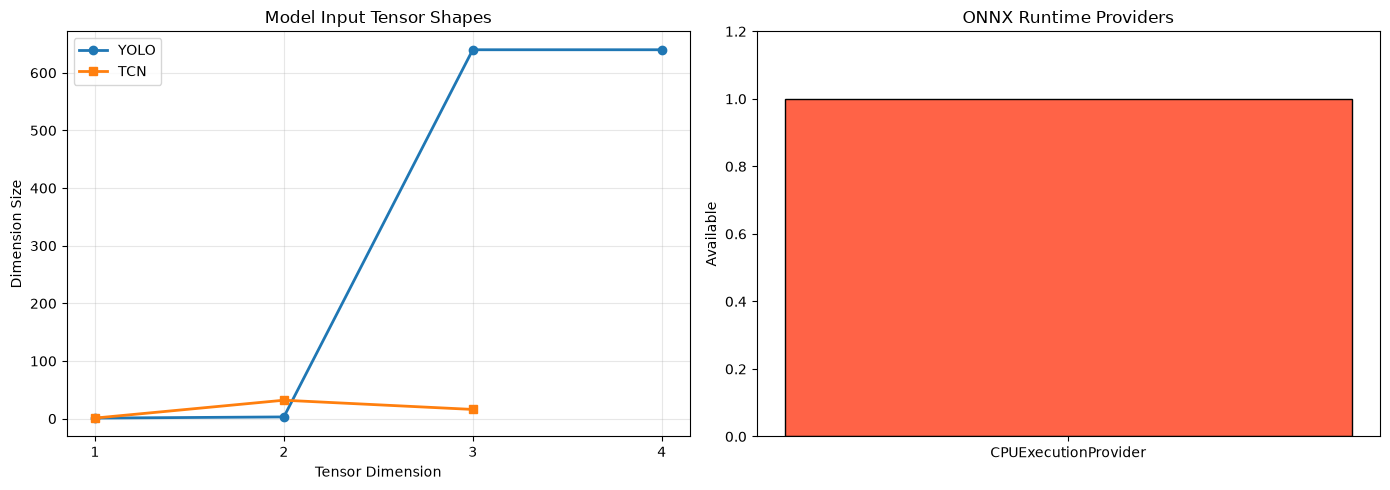

In [24]:
# Cell 2.1 — ONNX Session Overview (Matplotlib)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Model Input Dimensions ----
yolo_shape = yolo_session.get_inputs()[0].shape
tcn_shape  = tcn_session.get_inputs()[0].shape

def numeric_dims(shape):
    dims = []
    for d in shape:
        if isinstance(d, int):
            dims.append(d)
        else:
            dims.append(1)      # dynamic dimension (e.g., 'batch')
    return dims

yolo_dims = numeric_dims(yolo_shape)
tcn_dims  = numeric_dims(tcn_shape)

axes[0].plot(range(1, len(yolo_dims)+1), yolo_dims,
             marker="o", linewidth=2, label="YOLO")
axes[0].plot(range(1, len(tcn_dims)+1), tcn_dims,
             marker="s", linewidth=2, label="TCN")

axes[0].set_xticks(range(1, max(len(yolo_dims), len(tcn_dims))+1))
axes[0].set_xlabel("Tensor Dimension")
axes[0].set_ylabel("Dimension Size")
axes[0].set_title("Model Input Tensor Shapes")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---- Execution Providers ----
providers = yolo_session.get_providers()

axes[1].bar(
    providers,
    [1] * len(providers),
    color=["tomato" if "CPU" in p else "mediumseagreen" for p in providers],
    edgecolor="black"
)

axes[1].set_ylim(0, 1.2)
axes[1].set_title("ONNX Runtime Providers")
axes[1].set_ylabel("Available")

plt.tight_layout()
plt.show()

Cell 3 — YOLOv8 Pre/Post-processing Helpers

In [25]:
# Cell 3 — YOLOv8 Pre/Post-processing Helpers

def preprocess_frame(frame_bgr: np.ndarray, img_size: int = IMG_SIZE):
    """Resize + normalize a BGR frame for YOLOv8 ONNX input."""
    img = cv2.resize(frame_bgr, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))          # HWC → CHW
    img = np.expand_dims(img, axis=0)            # → (1, 3, H, W)
    return img


def nms(boxes, scores, iou_threshold=IOU_THRES):
    """Simple NumPy NMS — avoids torchvision dependency at inference."""
    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas  = (x2 - x1) * (y2 - y1)
    order  = scores.argsort()[::-1]
    keep   = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter  = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou    = inter / (areas[i] + areas[order[1:]] - inter + 1e-6)
        order  = order[1:][iou <= iou_threshold]
    return keep


def postprocess_yolo(output: np.ndarray, orig_h: int, orig_w: int,
                     conf_thres: float = CONF_THRES):
    """
    Parse YOLOv8 ONNX output → tool presence vector (7,) + detections list.
    YOLOv8 output shape: (1, 4+num_classes, num_anchors)
    """
    preds = output[0]                    # (4+7, num_anchors)
    preds = preds.T                      # (num_anchors, 11)

    boxes_xywh  = preds[:, :4]
    class_probs = preds[:, 4:]           # (num_anchors, 7)
    class_ids   = class_probs.argmax(axis=1)
    confidences = class_probs.max(axis=1)

    mask  = confidences >= conf_thres
    boxes_xywh  = boxes_xywh[mask]
    confidences = confidences[mask]
    class_ids   = class_ids[mask]

    # xywh → xyxy, scale back to original image
    sx, sy = orig_w / IMG_SIZE, orig_h / IMG_SIZE
    x1 = (boxes_xywh[:, 0] - boxes_xywh[:, 2] / 2) * sx
    y1 = (boxes_xywh[:, 1] - boxes_xywh[:, 3] / 2) * sy
    x2 = (boxes_xywh[:, 0] + boxes_xywh[:, 2] / 2) * sx
    y2 = (boxes_xywh[:, 1] + boxes_xywh[:, 3] / 2) * sy
    boxes_xyxy = np.stack([x1, y1, x2, y2], axis=1)

    # NMS
    keep = nms(boxes_xyxy, confidences) if len(boxes_xyxy) > 0 else []

    detections = []
    tool_presence = np.zeros(len(TOOL_COLS), dtype=np.float32)

    for idx in keep:
        cid  = class_ids[idx]
        conf = float(confidences[idx])
        box  = boxes_xyxy[idx].tolist()
        detections.append({
            "tool":  TOOL_COLS[cid],
            "conf":  round(conf, 3),
            "box":   [round(v, 1) for v in box]
        })
        tool_presence[cid] = 1.0

    return tool_presence, detections
print("YOLOv8 pre/post-processing helpers loaded.")

YOLOv8 pre/post-processing helpers loaded.


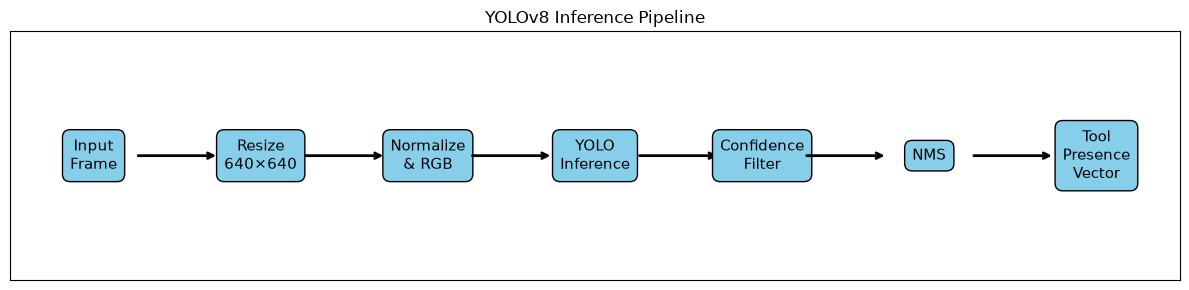

In [26]:
# Cell 3.1 — YOLO Pipeline Overview (Matplotlib)

fig, ax = plt.subplots(figsize=(12, 3))

steps = [
    "Input\nFrame",
    "Resize\n640×640",
    "Normalize\n& RGB",
    "YOLO\nInference",
    "Confidence\nFilter",
    "NMS",
    "Tool\nPresence\nVector"
]

x = np.arange(len(steps))

for i, step in enumerate(steps):
    ax.text(
        x[i], 0.5, step,
        ha="center", va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="skyblue",
                  edgecolor="black")
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x[i+1]-0.25, 0.5),
            xytext=(x[i]+0.25, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

ax.set_xlim(-0.5, len(steps)-0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("YOLOv8 Inference Pipeline")

plt.tight_layout()
plt.show()

Cell 4 — TCN Feature Builder & Phase Predictor

In [27]:
# Cell 4 — TCN Feature Builder & Phase Predictor

def build_feature_vector(tool_presence: np.ndarray,
                         window: deque,
                         frame_norm: float) -> np.ndarray:
    """
    Construct the 16-dim feature vector matching training:
      [7 tool binary] + [tool_count] + [frame_norm] + [7 roll5 means]
    """
    tool_count = float(tool_presence.sum())

    # Rolling mean over last 5 frames in the window
    window_arr = np.array(window)                        # (<=32, 7)
    roll_start = max(0, len(window_arr) - 5)
    roll5      = window_arr[roll_start:].mean(axis=0)    # (7,)

    feat = np.concatenate([
        tool_presence,                  # 7
        [tool_count],                   # 1
        [frame_norm],                   # 1
        roll5                           # 7
    ])                                  # → 16
    return feat.astype(np.float32)


def predict_phase(tcn_window: np.ndarray) -> tuple[str, float]:
    """
    Run TCN ONNX on a (SEQ_LEN, 16) window → (phase_name, confidence).
    """
    x = tcn_window[np.newaxis, :, :]                     # (1, 32, 16)
    logits = tcn_session.run(
        [tcn_output_name], {tcn_input_name: x}
    )[0][0]                                               # (7,)

    probs      = np.exp(logits) / np.exp(logits).sum()   # softmax
    phase_idx  = int(probs.argmax())
    confidence = float(probs[phase_idx])
    return PHASE_NAMES[phase_idx], round(confidence, 3)
print("TCN feature builder & phase predictor loaded.")

TCN feature builder & phase predictor loaded.


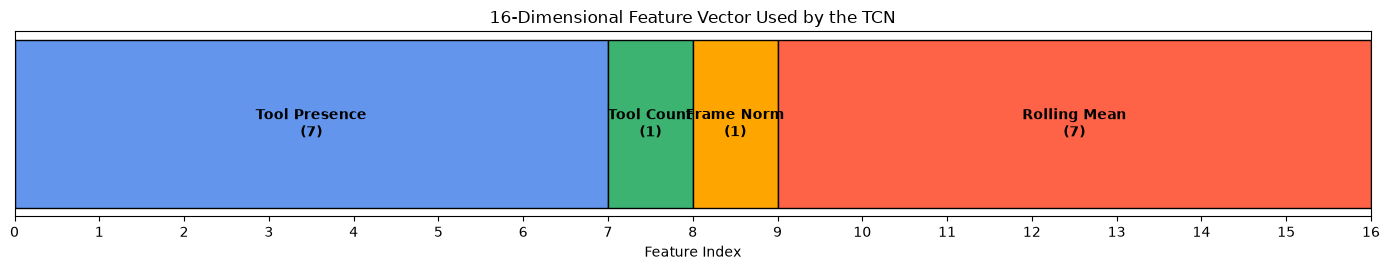

In [28]:
# Cell 4.1 — TCN Feature Vector Structure (Matplotlib)

fig, ax = plt.subplots(figsize=(14, 2.8))

feature_groups = [
    ("Tool Presence\n(7)", 7, "cornflowerblue"),
    ("Tool Count\n(1)", 1, "mediumseagreen"),
    ("Frame Norm\n(1)", 1, "orange"),
    ("Rolling Mean\n(7)", 7, "tomato"),
]

start = 0
for label, width, color in feature_groups:
    ax.barh(
        y=0,
        width=width,
        left=start,
        height=0.6,
        color=color,
        edgecolor="black"
    )
    ax.text(
        start + width / 2,
        0,
        label,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
    start += width

ax.set_xlim(0, 16)
ax.set_xticks(range(17))
ax.set_yticks([])
ax.set_xlabel("Feature Index")
ax.set_title("16-Dimensional Feature Vector Used by the TCN")

plt.tight_layout()
plt.show()

Cell 5 — Single-Video Inference Runner

In [29]:
# Cell 5 — Single-Video Inference Runner

def run_inference_on_video(video_id: str, max_frames: int = 200):
    """
    Run full ORAS pipeline on extracted frames of one video.
    Returns a DataFrame with per-frame results.
    """
    video_dir = FRAMES_DIR / video_id
    if not video_dir.exists():
        raise FileNotFoundError(f"Frame directory not found: {video_dir}")

    frame_files = sorted(video_dir.glob("*.jpg"))
    frame_files = frame_files[:max_frames]
    total       = len(frame_files)
    print(f"Processing {video_id}: {total} frames")

    # Rolling window of tool presence (for roll5 computation)
    tool_window  = deque(maxlen=32)
    # TCN input window of full feature vectors
    feat_window  = deque(maxlen=SEQ_LEN)

    # Pad feature window with zeros so we can predict from frame 1
    for _ in range(SEQ_LEN):
        feat_window.append(np.zeros(16, dtype=np.float32))
        tool_window.append(np.zeros(7, dtype=np.float32))

    results = []
    t0 = time.time()

    for i, fpath in enumerate(frame_files):
        frame_bgr = cv2.imread(str(fpath))
        if frame_bgr is None:
            continue

        orig_h, orig_w = frame_bgr.shape[:2]

        # ── YOLO ──────────────────────────────────────────────────────────────
        inp    = preprocess_frame(frame_bgr)
        output = yolo_session.run([yolo_output_name], {yolo_input_name: inp})[0]
        tool_presence, detections = postprocess_yolo(output, orig_h, orig_w)

        # ── Feature vector ────────────────────────────────────────────────────
        frame_norm = i / (total - 1 + 1e-6)
        tool_window.append(tool_presence.copy())
        feat_vec = build_feature_vector(tool_presence, tool_window, frame_norm)
        feat_window.append(feat_vec)

        # ── TCN ───────────────────────────────────────────────────────────────
        tcn_input   = np.array(feat_window, dtype=np.float32)   # (32, 16)
        phase, conf = predict_phase(tcn_input)

        results.append({
            "frame":      fpath.stem,
            "frame_idx":  i,
            "tools":      [d["tool"] for d in detections],
            "tool_count": int(tool_presence.sum()),
            "phase":      phase,
            "phase_conf": conf,
        })

        if (i + 1) % 50 == 0:
            elapsed = time.time() - t0
            fps     = (i + 1) / elapsed
            print(f"  [{i+1:>4}/{total}]  phase={phase:<30}  fps={fps:.1f}")

    elapsed = time.time() - t0
    print(f"\nDone. {total} frames in {elapsed:.1f}s  ({total/elapsed:.1f} fps)")
    return pd.DataFrame(results)
print("Single-video inference runner loaded.")

Single-video inference runner loaded.


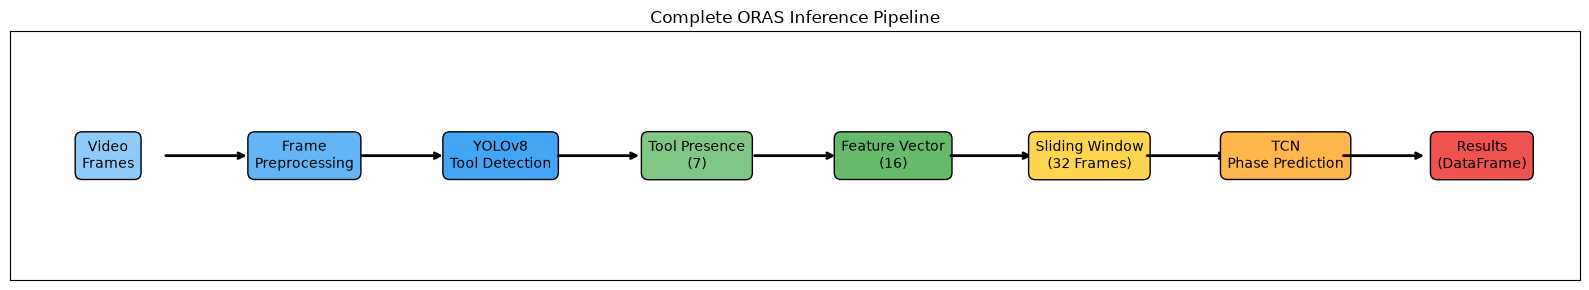

In [30]:
# Cell 5.1 — ORAS Inference Pipeline Overview (Matplotlib)

fig, ax = plt.subplots(figsize=(16, 3))

steps = [
    "Video\nFrames",
    "Frame\nPreprocessing",
    "YOLOv8\nTool Detection",
    "Tool Presence\n(7)",
    "Feature Vector\n(16)",
    "Sliding Window\n(32 Frames)",
    "TCN\nPhase Prediction",
    "Results\n(DataFrame)"
]

x = np.arange(len(steps))

colors = [
    "#90CAF9",
    "#64B5F6",
    "#42A5F5",
    "#81C784",
    "#66BB6A",
    "#FFD54F",
    "#FFB74D",
    "#EF5350"
]

for i, (step, color) in enumerate(zip(steps, colors)):
    ax.text(
        x[i], 0.5, step,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor=color,
            edgecolor="black"
        )
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x[i + 1] - 0.28, 0.5),
            xytext=(x[i] + 0.28, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2)
        )

ax.set_xlim(-0.5, len(steps) - 0.5)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Complete ORAS Inference Pipeline")

plt.tight_layout()
plt.show()

Cell 6 — Run on One Test Video

In [31]:
# Cell 6 — Run on One Test Video
# Pick the first video available in frames directory
available = sorted([d.name for d in FRAMES_DIR.iterdir() if d.is_dir()])
print(f"Available videos: {available[:5]} ...")

TEST_VIDEO = available[0]   # e.g. "video01"
df_result  = run_inference_on_video(TEST_VIDEO, max_frames=200)
print(df_result.head(10))

Available videos: ['video01', 'video02', 'video03', 'video04', 'video05'] ...
Processing video01: 200 frames
  [  50/200]  phase=CalotTriangleDissection         fps=11.2
  [ 100/200]  phase=CalotTriangleDissection         fps=11.4
  [ 150/200]  phase=GallbladderDissection           fps=11.3
  [ 200/200]  phase=GallbladderDissection           fps=11.1

Done. 200 frames in 18.0s  (11.1 fps)
    frame  frame_idx      tools  tool_count        phase  phase_conf
0  000000          0  [grasper]           1  Preparation       0.993
1  000025          1  [grasper]           1  Preparation       0.993
2  000050          2  [grasper]           1  Preparation       0.992
3  000075          3         []           0  Preparation       0.993
4  000100          4         []           0  Preparation       0.991
5  000125          5         []           0  Preparation       0.992
6  000150          6  [grasper]           1  Preparation       0.989
7  000175          7  [grasper]           1  Preparation

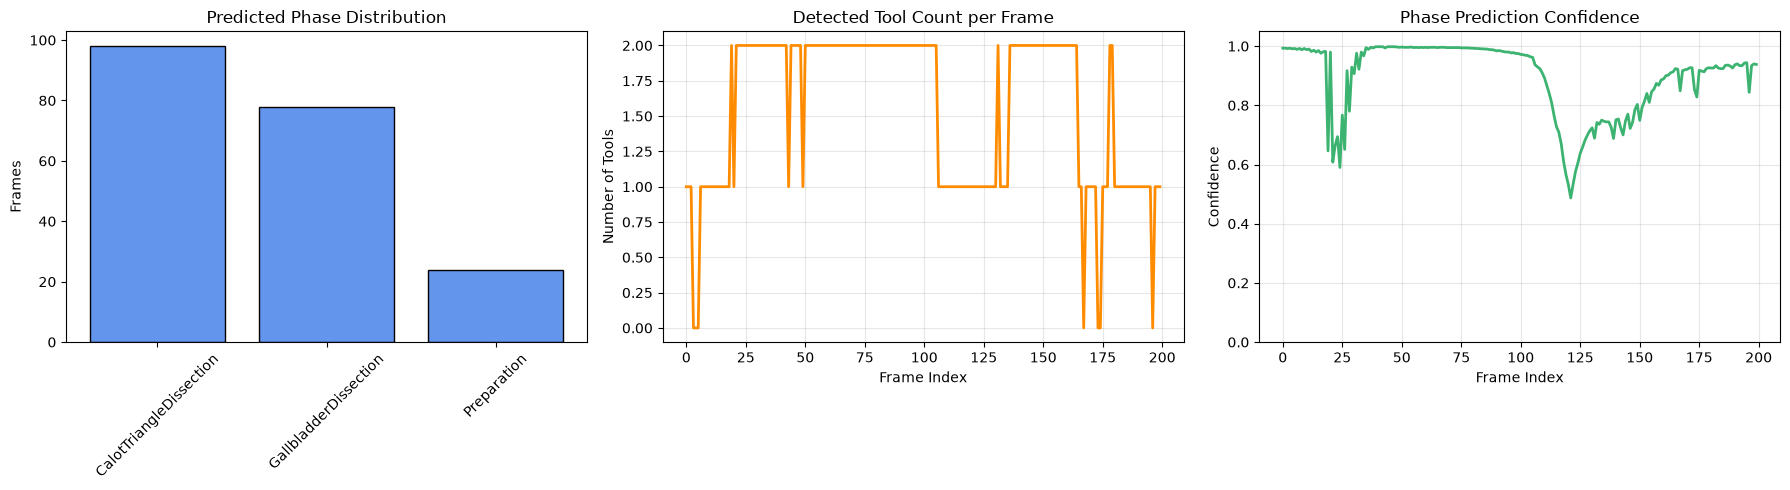

In [32]:
# Cell 6.1 — Inference Results Visualization (Matplotlib)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Predicted phase distribution
phase_counts = df_result["phase"].value_counts()

axes[0].bar(
    phase_counts.index,
    phase_counts.values,
    color="cornflowerblue",
    edgecolor="black"
)
axes[0].set_title("Predicted Phase Distribution")
axes[0].set_ylabel("Frames")
axes[0].tick_params(axis="x", rotation=45)

# 2. Tool count over time
axes[1].plot(
    df_result["frame_idx"],
    df_result["tool_count"],
    color="darkorange",
    linewidth=2
)
axes[1].set_title("Detected Tool Count per Frame")
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Number of Tools")
axes[1].grid(alpha=0.3)

# 3. Phase confidence over time
axes[2].plot(
    df_result["frame_idx"],
    df_result["phase_conf"],
    color="mediumseagreen",
    linewidth=2
)
axes[2].set_title("Phase Prediction Confidence")
axes[2].set_xlabel("Frame Index")
axes[2].set_ylabel("Confidence")
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Cell 7 — Results Visualization

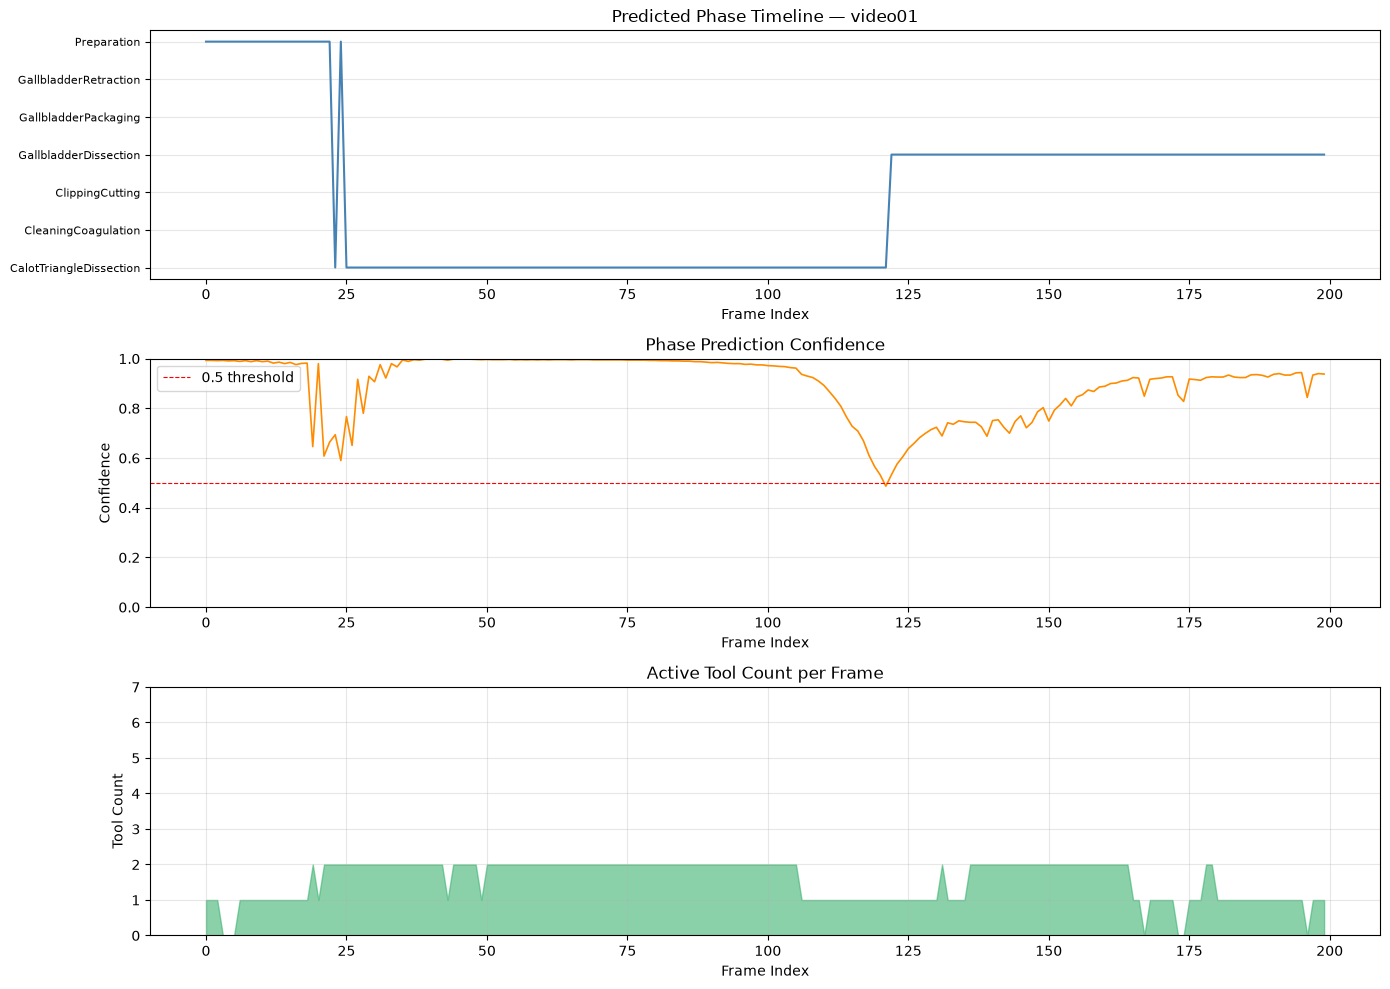

In [33]:
# Cell 7 — Results Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── 1. Phase timeline ──────────────────────────────────────────────────────────
phase_to_int = {p: i for i, p in enumerate(PHASE_NAMES)}
int_phases   = df_result["phase"].map(phase_to_int)
axes[0].plot(df_result["frame_idx"], int_phases, linewidth=1.5, color="steelblue")
axes[0].set_yticks(range(len(PHASE_NAMES)))
axes[0].set_yticklabels(PHASE_NAMES, fontsize=8)
axes[0].set_title(f"Predicted Phase Timeline — {TEST_VIDEO}")
axes[0].set_xlabel("Frame Index")
axes[0].grid(axis="y", alpha=0.3)

# ── 2. Phase confidence ────────────────────────────────────────────────────────
axes[1].plot(df_result["frame_idx"], df_result["phase_conf"],
             color="darkorange", linewidth=1.2)
axes[1].axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="0.5 threshold")
axes[1].set_ylim(0, 1)
axes[1].set_title("Phase Prediction Confidence")
axes[1].set_xlabel("Frame Index")
axes[1].set_ylabel("Confidence")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── 3. Tool count over time ────────────────────────────────────────────────────
axes[2].fill_between(df_result["frame_idx"], df_result["tool_count"],
                     alpha=0.6, color="mediumseagreen")
axes[2].set_title("Active Tool Count per Frame")
axes[2].set_xlabel("Frame Index")
axes[2].set_ylabel("Tool Count")
axes[2].set_ylim(0, 7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{TEST_VIDEO}_inference.png", dpi=150)
plt.show()

Cell 8 — Save Results CSV + Summary

In [34]:
# Cell 8 — Save Results CSV + Summary
out_csv = OUTPUT_DIR / f"{TEST_VIDEO}_results.csv"
df_result.to_csv(out_csv, index=False)
print(f"✓ Saved → {out_csv}")

print("\n── Phase Distribution in Predictions ──")
print(df_result["phase"].value_counts())

print("\n── Average Confidence per Phase ──")
print(df_result.groupby("phase")["phase_conf"].mean().round(3).sort_values())

print("\n── Tool Co-occurrence ──")
all_tools_flat = [t for tools in df_result["tools"] for t in tools]
from collections import Counter
print(Counter(all_tools_flat).most_common())

✓ Saved → D:\Projects\oras\ml\outputs\inference\video01_results.csv

── Phase Distribution in Predictions ──
phase
CalotTriangleDissection    98
GallbladderDissection      78
Preparation                24
Name: count, dtype: int64

── Average Confidence per Phase ──
phase
GallbladderDissection      0.832
Preparation                0.927
CalotTriangleDissection    0.939
Name: phase_conf, dtype: float64

── Tool Co-occurrence ──
[('hook', 175), ('grasper', 102), ('scissors', 22), ('bipolar', 9), ('clipper', 1)]


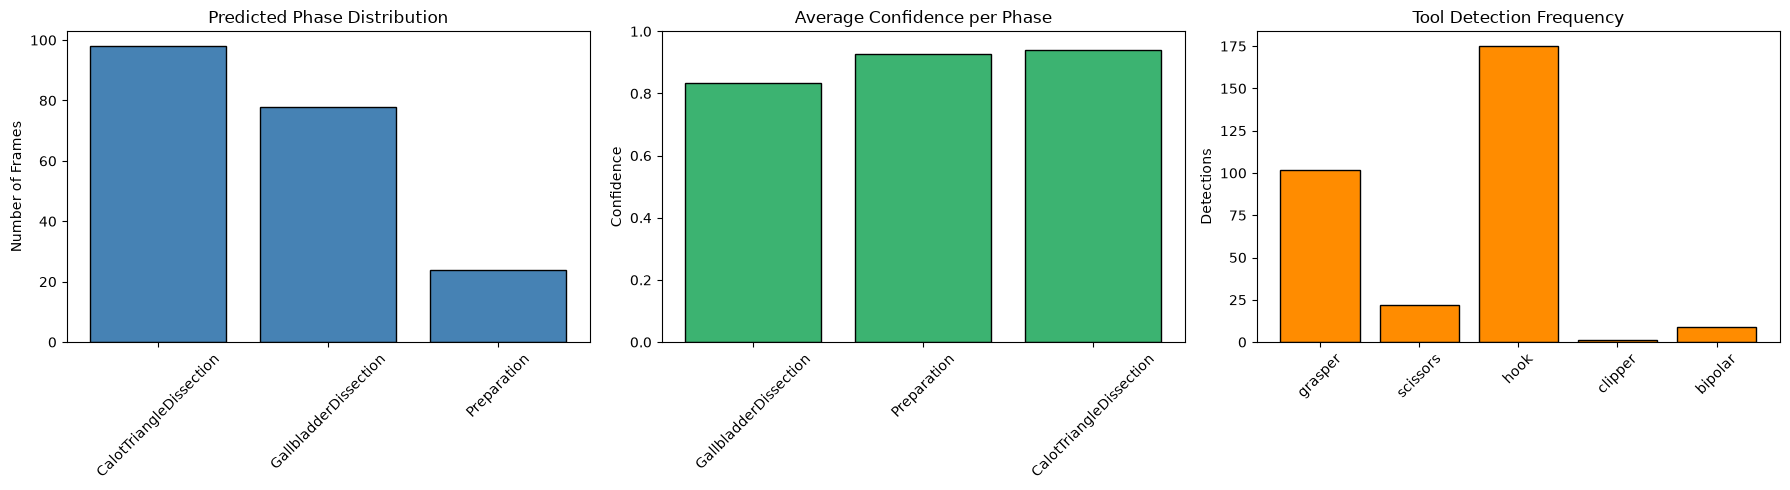

In [35]:
# Cell 8.1 — Prediction Summary Visualization (Matplotlib)

from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Phase Distribution
phase_counts = df_result["phase"].value_counts()

axes[0].bar(
    phase_counts.index,
    phase_counts.values,
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Predicted Phase Distribution")
axes[0].set_ylabel("Number of Frames")
axes[0].tick_params(axis="x", rotation=45)

# 2. Average Confidence by Phase
avg_conf = df_result.groupby("phase")["phase_conf"].mean().sort_values()

axes[1].bar(
    avg_conf.index,
    avg_conf.values,
    color="mediumseagreen",
    edgecolor="black"
)
axes[1].set_ylim(0, 1)
axes[1].set_title("Average Confidence per Phase")
axes[1].set_ylabel("Confidence")
axes[1].tick_params(axis="x", rotation=45)

# 3. Tool Detection Frequency
tool_counts = Counter(t for tools in df_result["tools"] for t in tools)

axes[2].bar(
    list(tool_counts.keys()),
    list(tool_counts.values()),
    color="darkorange",
    edgecolor="black"
)
axes[2].set_title("Tool Detection Frequency")
axes[2].set_ylabel("Detections")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()